<a href="https://colab.research.google.com/github/anurodh123/Image_Processing_And_Pattern_Recognition/blob/main/Lab4/Image%20Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
# Importing Required Libraries
import cv2
import matplotlib.pyplot as plt
import numpy as np

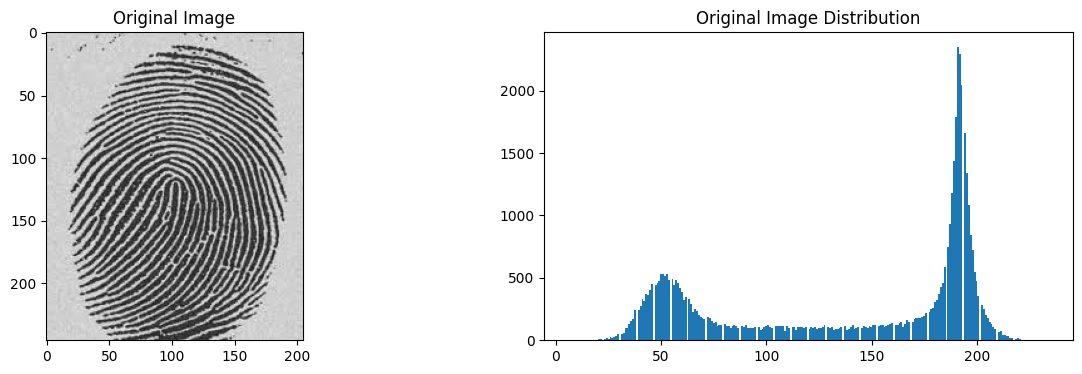

In [9]:
image = cv2.imread('/content/fingerprint.jpg', cv2.IMREAD_GRAYSCALE)
fig = plt.figure(figsize=(15, 4))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)
ax1.imshow(image, cmap='gray')
ax1.title.set_text('Original Image')
ax2.hist(image.ravel(), bins=256)
ax2.title.set_text('Original Image Distribution')

In [10]:
# Computing T Values until difference in T is smaller than T0
T = (np.max(image) + np.min(image)) / 2.0 # Initial Estimate of T, ensure float
T0 = 0 # Using T0 as 0 means loop breaks when T_new == T
while True:
  print(f'Thresholding Value: {T}')
  # Convert image.ravel() to a NumPy array for efficient filtering
  flat_image = image.ravel()
  # Filter pixels into two groups
  u1_pixels = flat_image[flat_image > T]
  u2_pixels = flat_image[flat_image <= T]
  # Check for empty groups to prevent ZeroDivisionError
  # This scenario means the threshold has pushed all pixels to one side,
  # indicating convergence or an inability to find a bimodal split.
  # It's best to stop iterating to prevent errors.
  if len(u1_pixels) == 0 or len(u2_pixels) == 0:
    break

  # Calculate means. np.mean handles potential overflows for uint8 by upcasting if necessary.
  m1 = np.mean(u1_pixels)
  m2 = np.mean(u2_pixels)
  T_new = (m1 + m2) / 2.0 # Use float division
  if abs(T_new - T) <= T0: # T0 is 0, so breaks when T_new == T
    break
  else:
    T = T_new
global_thres = image > T

Thresholding Value: 120.0
Thresholding Value: 123.80825488637441
Thresholding Value: 124.58247077719997
Thresholding Value: 124.81656905710813


In [12]:
# Taking Threshold Value as the Mean in the Neighbourhood Area
#adaptiveThreshold(src, maxValue, adaptiveMethod, thresholdType, blockSize, C)
adaptive_thres = cv2.adaptiveThreshold(image, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, 13, 15)

In [13]:
#cv2.threshold(source, thresholdValue, maxVal, thresholdingTechnique)
ret, otsu_thres = cv2.threshold(image, 124, 255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)

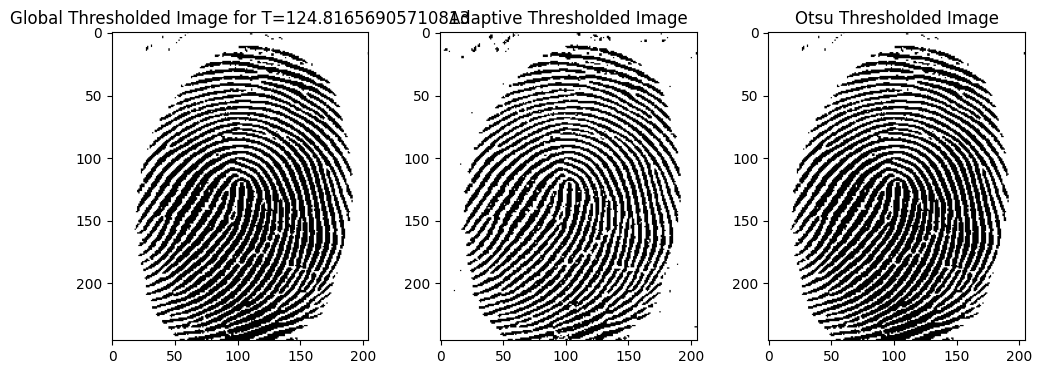

In [14]:
# Displaying Results of Thresholding Techniques
fig = plt.figure(figsize=(12, 4))
ax1 = fig.add_subplot(131)
ax2 = fig.add_subplot(132)
ax3 = fig.add_subplot(133)
ax1.imshow(global_thres, cmap='gray')
ax1.title.set_text(f'Global Thresholded Image for T={T}')
ax2.imshow(adaptive_thres, cmap='gray')
ax2.title.set_text(f'Adaptive Thresholded Image')
ax3.imshow(otsu_thres, cmap='gray')
ax3.title.set_text(f'Otsu Thresholded Image')

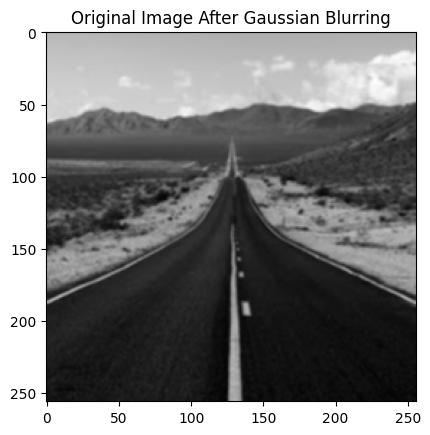

In [16]:
image = cv2.imread('/content/road.jpg', cv2.IMREAD_GRAYSCALE)
image = cv2.GaussianBlur(image, (3,3), 0)
plt.imshow(image, cmap='gray')
plt.title('Original Image After Gaussian Blurring')
plt.show()

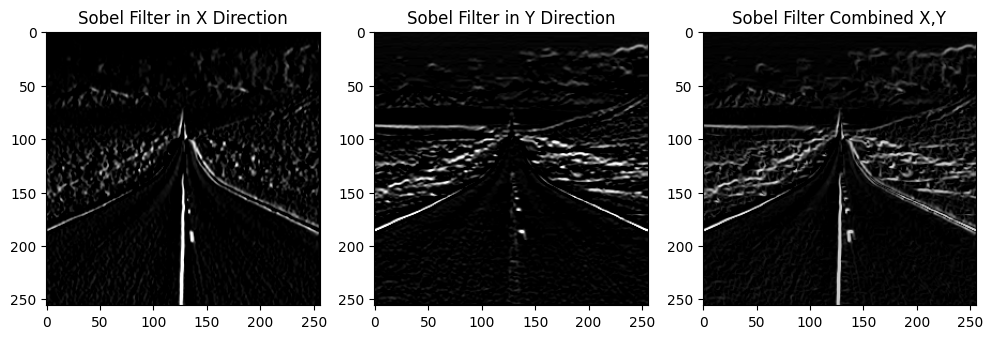

In [17]:
sobelX = cv2.Sobel(image, cv2.CV_8U, 1, 0, ksize=3).astype(np.uint64)
sobelY = cv2.Sobel(image, cv2.CV_8U, 0, 1, ksize=3).astype(np.uint64)
sobel = np.sqrt(np.power(sobelX, 2) + np.power(sobelY, 2)).astype(np.uint64)
fig = plt.figure(figsize=(12, 4))
ax1 = fig.add_subplot(131)
ax2 = fig.add_subplot(132)
ax3 = fig.add_subplot(133)
ax1.imshow(sobelX, cmap='gray')
ax1.title.set_text('Sobel Filter in X Direction')
ax2.imshow(sobelY, cmap='gray')
ax2.title.set_text('Sobel Filter in Y Direction')
ax3.imshow(sobel, cmap='gray')
ax3.title.set_text('Sobel Filter Combined X,Y')

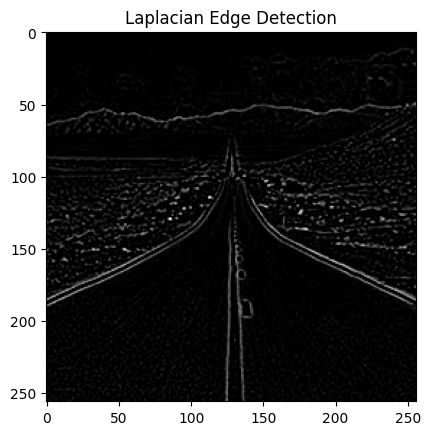

In [18]:
laplacian = cv2.Laplacian(image, cv2.CV_8U)
plt.imshow(laplacian, cmap='gray')
plt.title('Laplacian Edge Detection')
plt.show()

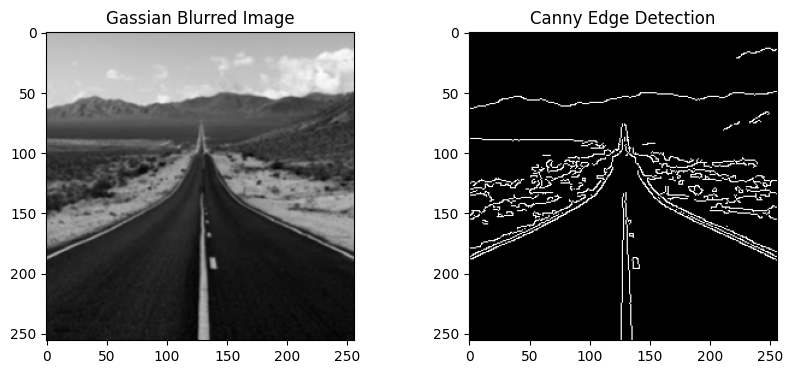

In [19]:
bTHRESHOLD1 = 100
THRESHOLD2 = 200
canny = cv2.Canny(image, THRESHOLD1, THRESHOLD2)
fig = plt.figure(figsize=(10, 4))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)
ax1.imshow(image, cmap='gray')
ax1.title.set_text('Gassian Blurred Image')
ax2.imshow(canny, cmap='gray')
ax2.title.set_text('Canny Edge Detection')

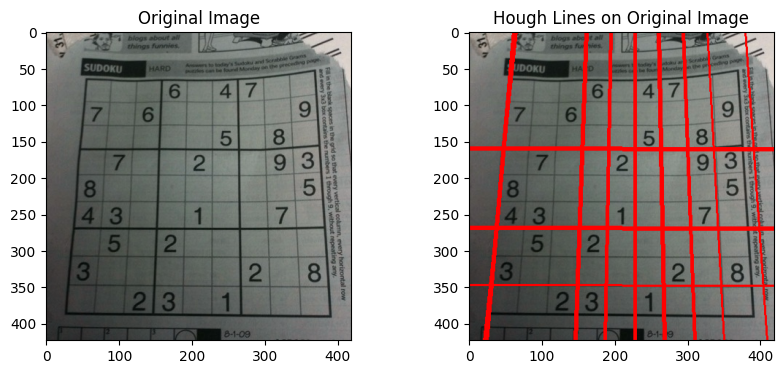

In [23]:
image = cv2.imread('/content/sudoku-original.jpg')
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
edges = cv2.Canny(gray, 50, 150, apertureSize=3)
lines = cv2.HoughLines(edges, 1, np.pi/180, 200)
for rt in lines:
  for rho, theta in rt:
    a = np.cos(theta)
    b = np.sin(theta)
    x0 = a*rho
    y0 = b*rho
    x1 = int(x0 + 1000*(-b))
    y1 = int(y0 + 1000*(a))
    x2 = int(x0 - 1000*(-b))
    y2 = int(y0 - 1000*(a))
    cv2.line(image, (x1,y1), (x2,y2), (255,0,), 2)

fig = plt.figure(figsize=(10, 4))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)
ax1.imshow(cv2.imread('/content/sudoku-original.jpg'))
ax1.title.set_text('Original Image')
ax2.imshow(image)
ax2.title.set_text('Hough Lines on Original Image')

In [24]:
# Using Point Detection Mask on Image
image = cv2.imread('/content/turbine.jpg', cv2.IMREAD_GRAYSCALE)
point_detection_mask = np.array([[-1,-1,-1],
[-1,8,-1],
[-1,-1,-1]])
filtered = cv2.filter2D(image, -1, point_detection_mask)

In [25]:
# Thresholding
T = 0.9 * np.max(filtered) # 90% of the highest absolute pixel value of the image filtered
thresh = filtered > T

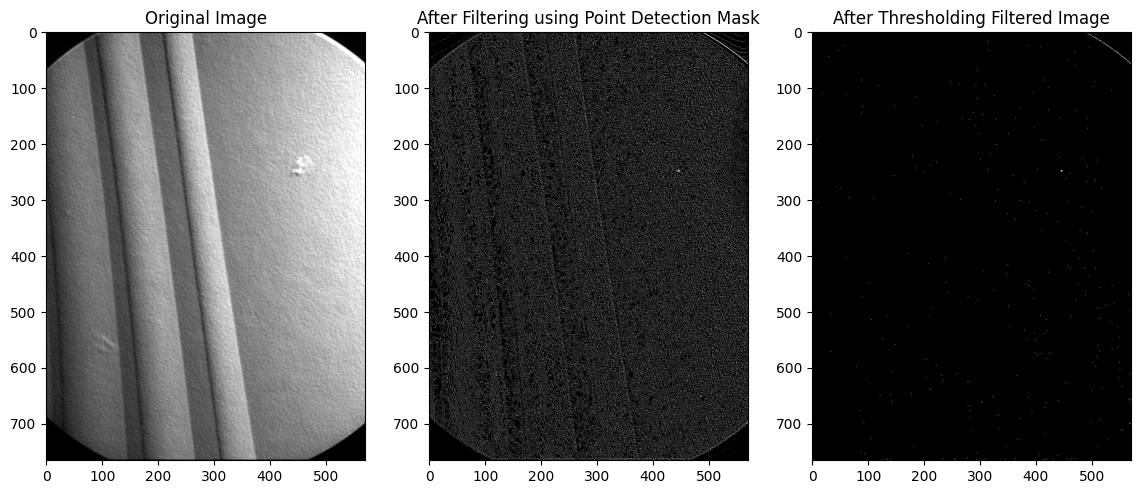

In [26]:
# Displaying Results
fig = plt.figure(figsize=(14, 12))
ax1 = fig.add_subplot(131)
ax2 = fig.add_subplot(132)
ax3 = fig.add_subplot(133)
ax1.imshow(image, cmap='gray')
ax1.title.set_text('Original Image')
ax2.imshow(filtered, cmap='gray')
ax2.title.set_text('After Filtering using Point Detection Mask')
ax3.imshow(thresh, cmap='gray')
ax3.title.set_text('After Thresholding Filtered Image')